# H.E.A.R.T
## Helping Every At-Risk Mother Thrive

Import neccesary libraries

In [113]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [114]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

Load Dataset

In [115]:
df = pd.read_csv('/Users/gracysutaria/Documents/UCI/VenusHacks/H.E.A.R.T-/Maternal_health.csv')

In [116]:
df.shape

(1205, 12)

In [117]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Clean/Impute Data

In [118]:
df = df.dropna(subset=['Risk Level'])
df.shape

(1187, 12)

In [119]:
df['Risk Level'] = df['Risk Level'].str.strip().str.lower()

In [120]:
df.isna().sum()

Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64

In [121]:
continuous_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate']
for col in continuous_cols + ['Body Temp']:
        df[col] = df[col].fillna(df[col].median())


In [122]:
binary_cols = ['Previous Complications', 'Preexisting Diabetes']
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Outliers

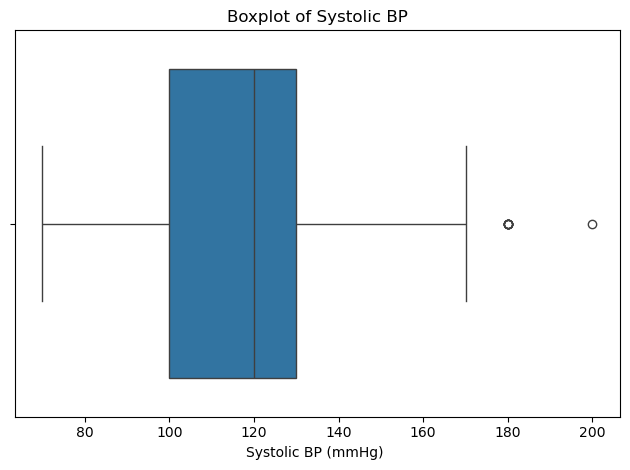

In [123]:
sns.boxplot(x=df['Systolic BP'])
plt.title("Boxplot of Systolic BP")
plt.xlabel("Systolic BP (mmHg) ")
plt.tight_layout()
plt.show()

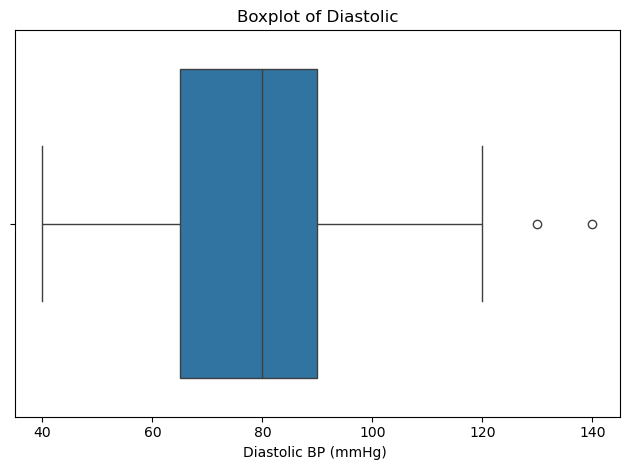

In [124]:
sns.boxplot(x=df['Diastolic'])
plt.title("Boxplot of Diastolic")
plt.xlabel("Diastolic BP (mmHg) ")
plt.tight_layout()
plt.show()

In [125]:
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 3 * IQR) & (df[col] <= Q3 + 3 * IQR)]

In [126]:
df.shape

(1100, 12)

In [127]:
df["PulsePressure"] = df["Systolic BP"] - df["Diastolic"]
# MAP: Mean Arterial Pressure - estimates the avverage blood pressure during one cardiac cycle
df["MAP"]           = (df["Systolic BP"] + 2 * df["Diastolic"]) / 3
# Diabete risk score
df["DiabetesRisk"]  = df["Preexisting Diabetes"] + df["Gestational Diabetes"]
# Split into age groups
df["AgeGroup"]      = pd.cut(df["Age"], bins=[0,20,30,40,100],
                              labels=["Teen","Young Adult","Adult","Mature"])
# Encode age group
df["AgeGroupEnc"]   = LabelEncoder().fit_transform(df["AgeGroup"].astype(str))

In [128]:
features = [
    "Age", "Systolic BP", "Diastolic", "BS", "Body Temp", "BMI", "Heart Rate",
    "Previous Complications", "Preexisting Diabetes", "Gestational Diabetes",
    "Mental Health", "PulsePressure", "MAP", "DiabetesRisk", "AgeGroupEnc",
]

df = df.drop_duplicates(subset=features)
df.reset_index(drop=True, inplace=True)

In [129]:
df.shape

(1081, 17)

### Encode Target

In [130]:
le = LabelEncoder()
df['RiskEncoded'] = le.fit_transform(df['Risk Level'])
label_map = {int(i): c for i, c in enumerate(le.classes_)}
label_map

{0: 'high', 1: 'low'}

### Train Test Split

In [131]:
X = df[features]
y = df['RiskEncoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=9, stratify=y
)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [132]:
X_train.shape

(864, 15)

In [133]:
X_test.shape

(217, 15)

In [134]:
models = {
    'Random Forest': (
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,           # prevents unlimited depth
            min_samples_leaf=5,     # each leaf needs ≥5 samples
            min_samples_split=10,   # each split needs ≥10 samples
            random_state=9,
        ),
        X_train, X_test,
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(
            n_estimators=150,
            max_depth=4,            # slightly deeper than default
            min_samples_leaf=5,
            subsample=0.8,          # stochastic: use 80% of data per tree
            random_state=9,
        ),
        X_train, X_test,
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=9),  # L2 by default
        X_train_s, X_test_s,
    ),
}

In [135]:
results = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds      = model.predict(Xte)
    train_acc  = accuracy_score(y_train, model.predict(Xtr))
    test_acc   = accuracy_score(y_test,  preds)
    gap        = train_acc - test_acc
    cv_scores  = cross_val_score(model, Xtr, y_train, cv=5, scoring="accuracy")
    report     = classification_report(y_test, preds, target_names=le.classes_, output_dict=True)
    cm         = confusion_matrix(y_test, preds).tolist()
 
    results[name] = {
        'train_acc': round(float(train_acc) * 100, 2),
        'test_acc':  round(float(test_acc)  * 100, 2),
        'gap':       round(float(gap)        * 100, 2),
        'cv_mean':   round(float(cv_scores.mean()) * 100, 2),
        'cv_std':    round(float(cv_scores.std())  * 100, 2),
        'report':    report,
        'cm':        cm,
    }
    status = "✓ Clean" if abs(gap) < 0.02 else ("⚠ Minor" if abs(gap) < 0.05 else "✗ Overfit")

In [136]:
cv_scores.mean()

np.float64(0.9710512165613657)

In [137]:
cv_scores.std()

np.float64(0.01101732155171077)

In [138]:
rf_model    = models['Random Forest'][0]
importances = {f: round(float(v)*100,2) for f,v in zip(features, rf_model.feature_importances_)}
best_model  = max(results, key=lambda k: results[k]['test_acc'])

In [139]:
print(f"\n  Best model : {best_model} @ {results[best_model]['test_acc']}% test accuracy")
print(f"\n  Feature importances (top 10, RF):")


  Best model : Gradient Boosting @ 99.08% test accuracy

  Feature importances (top 10, RF):


In [140]:
for feat, imp in sorted(importances.items(), key=lambda x: -x[1]):
    print(f"{feat:<30} {imp:5.2f}%  {'█'*int(imp/1.5)}")

DiabetesRisk                   31.31%  ████████████████████
Heart Rate                     11.25%  ███████
BS                             11.10%  ███████
BMI                            10.88%  ███████
Preexisting Diabetes           10.59%  ███████
Mental Health                  10.33%  ██████
Gestational Diabetes            4.48%  ██
Previous Complications          4.04%  ██
MAP                             1.79%  █
Systolic BP                     1.37%  
Diastolic                       1.33%  
Age                             0.79%  
PulsePressure                   0.32%  
Body Temp                       0.29%  
AgeGroupEnc                     0.13%  


In [141]:
output = dict(
    n_rows=len(df), removed_dupes=1081, n_features=len(features),
    features=features, classes=le.classes_.tolist(), label_map=label_map,
    results=results, importances=importances, best_model=best_model,
)
with open('H.E.A.R.T_results.json', 'w') as f:
    json.dump(output, f, indent=2, cls=NpEncoder)
print(f"\n  Saved: {'H.E.A.R.T_results.json'}")


  Saved: H.E.A.R.T_results.json


### Plots

In [152]:
palette = {
    'rf':    '#4C9FE8',   # blue  — Random Forest
    'gb':    '#3ECF9E',   # teal  — Gradient Boosting
    'lr':    '#A78BFA',   # purple— Logistic Regression
    'mild':  '#F4A537',   # amber
    'bad':   '#F06565',   # red
    'bg':    '#0F1117',
    'card':  '#1A1D27',
    'grid':  '#2E3246',
}
fig = plt.figure(figsize=(18, 20))
fig.suptitle(
    'Model Comparison — Maternal Health Risk Pipeline',
    fontsize=18, fontweight='bold', color='#E8EAF0', y=0.98)

Text(0.5, 0.98, 'Model Comparison — Maternal Health Risk Pipeline')

<Figure size 1800x2000 with 0 Axes>

In [143]:
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.38,
    left=0.06, right=0.97,
    top=0.94, bottom=0.04,
)

names   = list(results.keys())

model_colors = [palette['rf'], palette['gb'], palette['lr']]

colors  = model_colors

model_names_short = ['RF', 'GB', 'LR']

x  = np.arange(3)

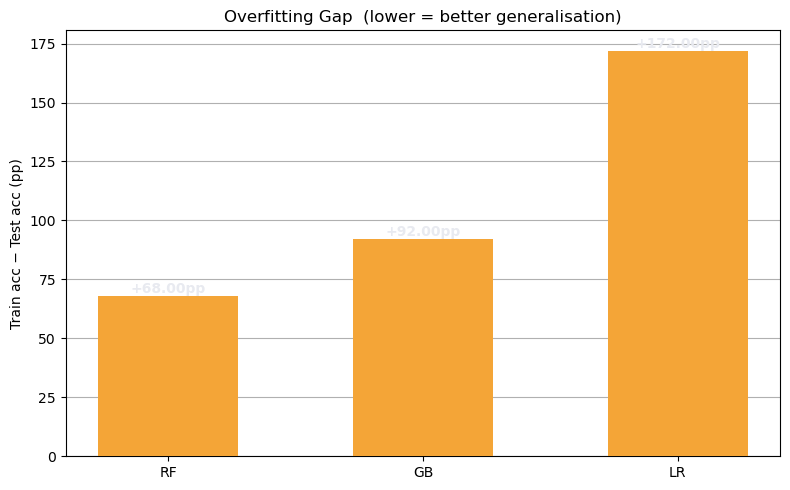

In [153]:
# Overfitting Gap 
fig, ax = plt.subplots(figsize=(8, 5))
gaps = [(results[n]['train_acc'] - results[n]['test_acc']) * 100 for n in names]
gap_colors = [palette['mild'] if abs(g) > 1 else palette['gb'] for g in gaps]

bars = ax.bar(x, gaps, 0.55, color=gap_colors, zorder=3)
ax.axhline(0, color='#E8EAF0', linewidth=0.8, linestyle='--', zorder=2)
for bar, val in zip(bars, gaps):
    ypos = val + 0.03 if val >= 0 else val - 0.12
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.2f}pp', ha='center', va='bottom', fontsize=10,
            color='#E8EAF0', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(model_names_short)
ax.set_ylabel('Train acc − Test acc (pp)')
ax.set_title('Overfitting Gap  (lower = better generalisation)')
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

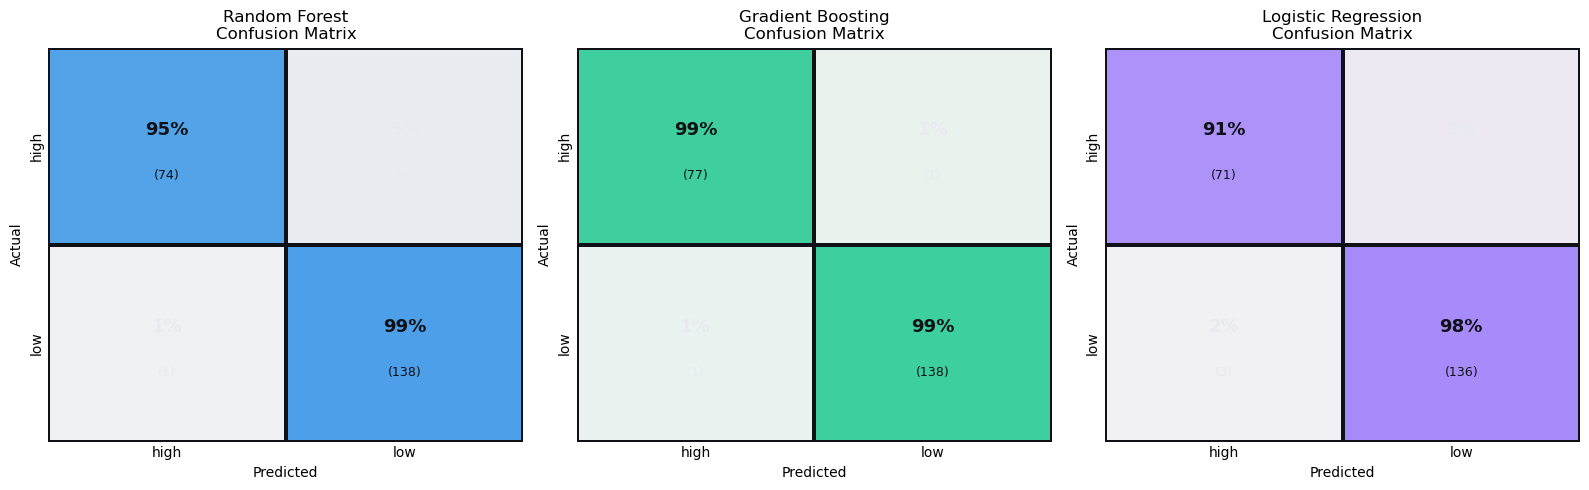

In [154]:
# Confusion Matrices 
classes = le.classes_.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, color in zip(axes, names, colors):
    cm     = np.array(results[name]['cm'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    cmap = sns.light_palette(color, as_cmap=True)
    sns.heatmap(cm_pct, annot=False, cmap=cmap, ax=ax, cbar=False,
                linewidths=1.5, linecolor=palette['bg'],
                xticklabels=classes, yticklabels=classes)

    for i in range(len(classes)):
        for j in range(len(classes)):
            pct = cm_pct[i, j]; cnt = cm[i, j]
            tc  = '#0F1117' if pct > 40 else '#E8EAF0'
            ax.text(j+0.5, i+0.42, f"{pct:.0f}%", ha='center', va='center',
                    fontsize=13, fontweight="bold", color=tc)
            ax.text(j+0.5, i+0.65, f"({cnt})",    ha='center', va='center',
                    fontsize=9, color=tc)

    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.tick_params(length=0)

plt.tight_layout()
plt.show()

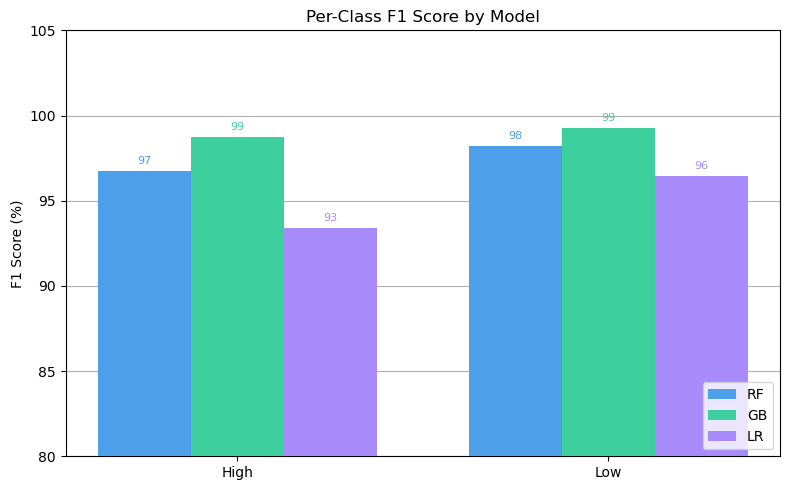

In [155]:
fig, ax = plt.subplots(figsize=(8, 5))
cls_x = np.arange(len(classes))
bar_w = 0.25

for i, (name, col) in enumerate(zip(names, colors)):
    f1s    = [results[name]['report'][cls]['f1-score'] * 100 for cls in classes]
    offset = (i - 1) * bar_w
    b = ax.bar(cls_x + offset, f1s, bar_w, color=col,
               label=model_names_short[i], zorder=3)
    for bar, val in zip(b, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.0f}", ha='center', va='bottom', fontsize=8, color=col)

ax.set_xticks(cls_x); ax.set_xticklabels([c.capitalize() for c in classes])
ax.set_ylim(80, 105); ax.set_ylabel('F1 Score (%)')
ax.set_title('Per-Class F1 Score by Model')
ax.legend(loc='lower right'); ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

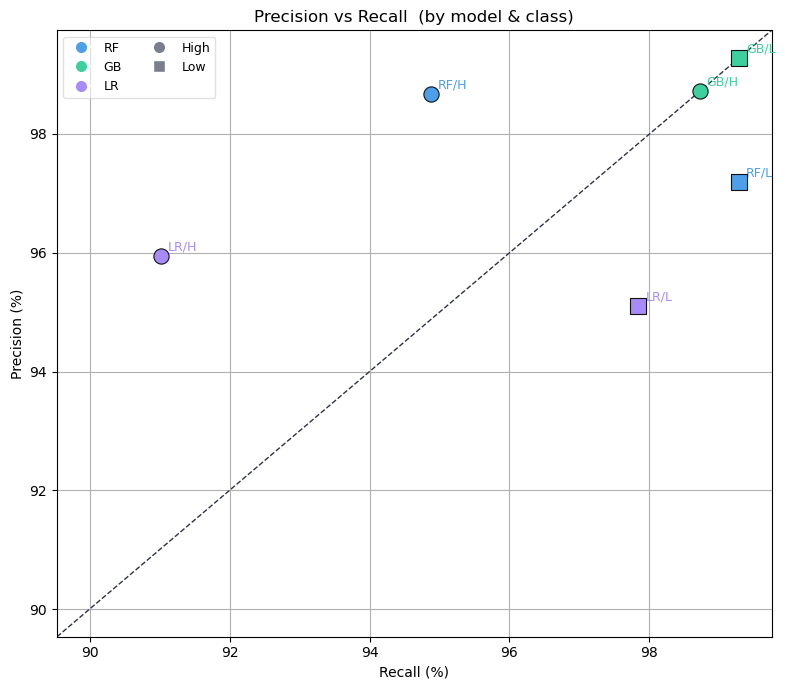

In [156]:
fig, ax = plt.subplots(figsize=(8, 7))
markers = ['o', 's']

for cls, marker in zip(classes, markers):
    for name, col, short in zip(names, colors, model_names_short):
        prec = results[name]['report'][cls]['precision'] * 100
        rec  = results[name]['report'][cls]['recall']    * 100
        ax.scatter(rec, prec, color=col, marker=marker, s=120, zorder=4,
                   edgecolors='#0F1117', linewidths=0.8)
        ax.annotate(f"{short}/{cls[:1].upper()}", (rec, prec),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=9, color=col)

ax.axline((90, 90), slope=1, color=palette['grid'], linewidth=1, linestyle="--")
ax.set_xlabel('Recall (%)'); ax.set_ylabel('Precision (%)')
ax.set_title('Precision vs Recall  (by model & class)')

from matplotlib.lines import Line2D
handles  = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
                   markersize=9, label=s)
            for c, s in zip(colors, model_names_short)]
handles += [Line2D([0],[0], marker=m, color='w', markerfacecolor='#7A7E8E',
                   markersize=9, label=cl.capitalize())
            for m, cl in zip(markers, classes)]
ax.legend(handles=handles, fontsize=9, framealpha=0.6, ncol=2)
ax.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

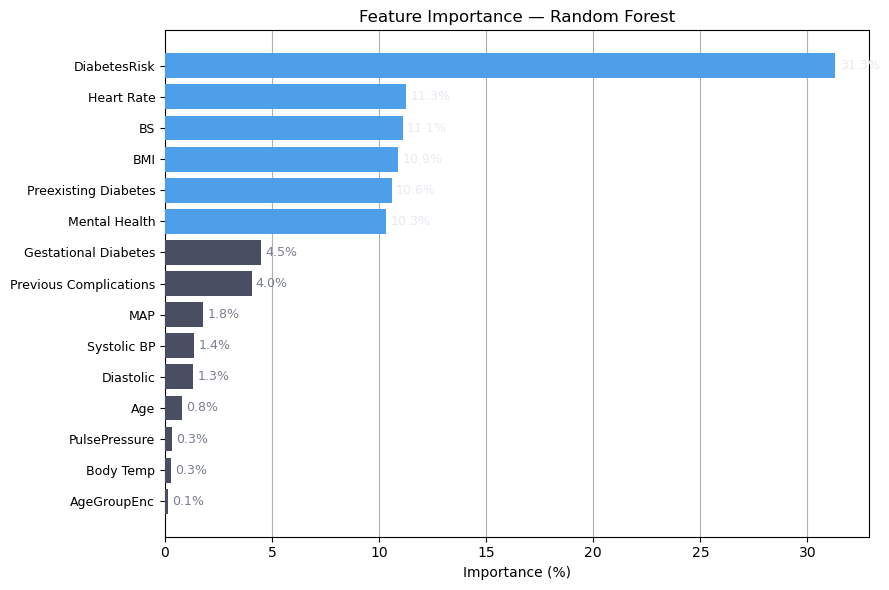

In [157]:
fig, ax = plt.subplots(figsize=(9, 6))
#rf_importances = dict(zip(features, results["Random Forest"]["model"].feature_importances_))
rf_importances = dict(zip(features, rf_model.feature_importances_))
sorted_feats   = sorted(rf_importances.items(), key=lambda x: x[1])
feat_names     = [f[0] for f in sorted_feats]
feat_vals      = [f[1] * 100 for f in sorted_feats]
feat_colors    = [palette['rf'] if v > 10 else palette['mild'] if v > 5 else '#4A4E62'
                  for v in feat_vals]

bars = ax.barh(feat_names, feat_vals, color=feat_colors, zorder=3)
for bar, val in zip(bars, feat_vals):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9,
            color='#E8EAF0' if val > 5 else '#7A7E8E')

ax.set_xlabel('Importance (%)'); ax.set_title('Feature Importance — Random Forest')
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

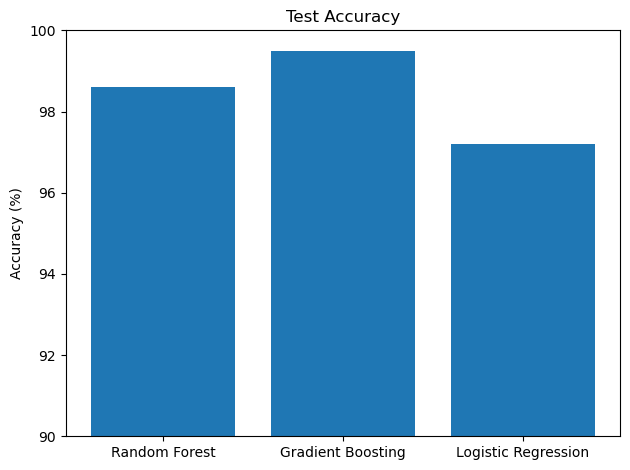

In [151]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['Random Forest', 'Gradient Boosting', 'Logistic Regression'],
        [98.6, 99.5, 97.2])
plt.title('Test Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 100)
plt.tight_layout()
plt.show()